# Lagrangian Coherent Structure (LCS) Map Around the Cabo Verde Region

This notebook maps LCS's around the Cabo Verde area by computing **eigen values**.

## Workflow Overview

1. **Load ocean current data** from Copernicus Marine Service (CMES) sea surface current (`cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m`) NetCDF dataset
2. **Set up an Parcels fieldset** from the xarray dataset
3. **Initialise a particle grid** with triplet clusters for deformation gradient computation
4. **Advect particles** forward in time using the RK4 advection kernel
5. **Compute the deformation gradient tensor** $\mathbf{F}$ and Cauchy-Green strain tensor $\mathbf{C}$
6. **Compute eigen values** and extract the maximum eigenvalue of $\mathbf{C}$
7. **Visualise LCS** from maximum eigenvalues

In [1]:
import math
from datetime import timedelta
from operator import attrgetter

import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

import parcels
from parcels import StatusCode

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Load and Prepare Ocean Current Data

In [2]:
flowfield_env = xr.open_dataset('/work/bk1450/b384140/cmems_mod_glo_phy-curr.nc')
flowfield_env = flowfield_env.squeeze()
flowfield_env

<xarray.Dataset> Size: 751kB
Dimensions:    (time: 31, latitude: 55, longitude: 55)
Coordinates:
  * time       (time) datetime64[ns] 248B 2025-08-01 2025-08-02 ... 2025-08-31
  * latitude   (latitude) float32 220B 13.5 13.58 13.67 ... 17.83 17.92 18.0
  * longitude  (longitude) float32 220B -26.5 -26.42 -26.33 ... -22.08 -22.0
    depth      float32 4B 0.494
Data variables:
    uo         (time, latitude, longitude) float32 375kB ...
    vo         (time, latitude, longitude) float32 375kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

### Boundary Conditions

Velocity values at the **domain edges** are set to zero to enforce closed boundary conditions and prevent particles from escaping the domain.

In [3]:
# meridional velocity
flowfield_env.uo.data[:,:,0]=0 # western boundary
flowfield_env.uo.data[:,:,-1]=0 # eastern boundary
flowfield_env.uo.data[:,0,:]=0 # southern boundary
flowfield_env.uo.data[:,-1,:]=0 # northern boundary

# zonal velocity
flowfield_env.vo.data[:,:,0]=0
flowfield_env.vo.data[:,:,-1]=0
flowfield_env.vo.data[:,0,:]=0
flowfield_env.vo.data[:,-1,:]=0

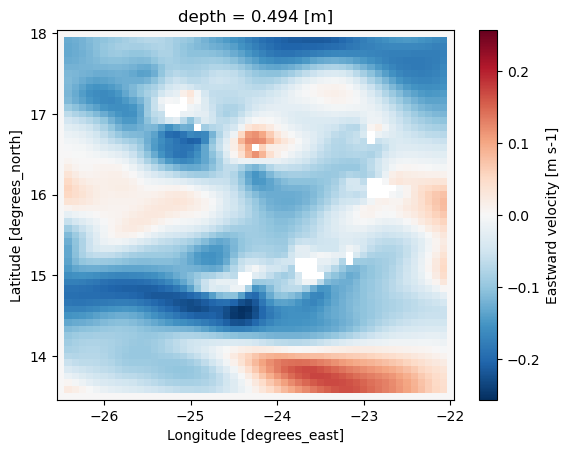

In [4]:
# Visual check
flowfield_env.uo.mean("time").plot()

## Parameters

In [5]:
# geospatial sextent of the Cabo Verde region
lon_min = -26
lon_max = -22.5
lat_min = 14
lat_max = 17.5

grid_points_lon = 100
grid_points_lat = 100

perturbation_delta = 0.02  # degrees

integration_days = 10

# number of particle/eigenvector samples to draw in diagnostic plots
eigenvector_plot_count = 10000

## Parcels Fieldset
xarray dataset variables and dimensions are mapped to the Parcels naming convention, then the `FieldSet` object is constructed and used to interpolate velocity during particle advection.

In [6]:
# Map dataset variable names to Parcels U/V convention
variables = {
    "U": "uo",
    "V": "vo",
}

# Map dataset coordinate names to Parcels U/V convention
dimensions = {
    "lon": "longitude",
    "lat": "latitude",
    "time": "time"
}

fieldset = parcels.FieldSet.from_xarray_dataset(flowfield_env, variables, dimensions)
print(fieldset)

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
            extrapolate time: False
            time_periodic   : False
            gridindexingtype: 'nemo'
            to_write        : False
        <Field>
            name            : 'V'
            grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)),

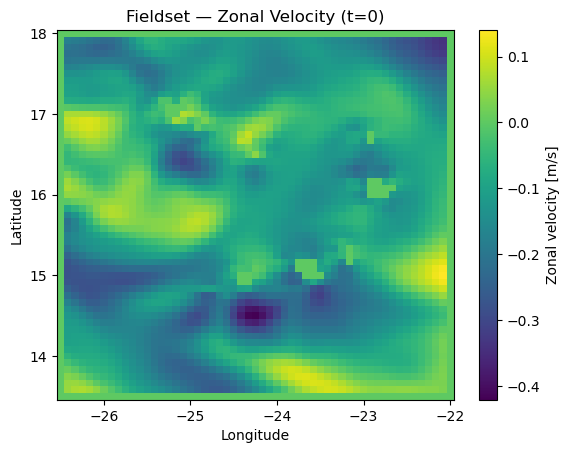

In [7]:
# visual check of first timestamp
fieldset.computeTimeChunk()

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Zonal velocity [m/s]")
plt.title("Fieldset — Zonal Velocity (t=0)")
plt.show()

## Initialise Particle Grid

### Setting up Triplets

Identifying LCS require the **deformation gradient tensor** $\mathbf{F}$, computed via finite differences. For each grid point, three particles are released:

| Role | Position |
|------|----------|
| **Centre** | $(\lambda, \phi)$ |
| **x-shifted** | $(\lambda + \delta, \phi)$ |
| **y-shifted** | $(\lambda, \phi + \delta)$ |

where $\delta$ is a small spatial perturbation. After advection, the displacement of the perturbed particles relative to the centre particle gives the columns of $\mathbf{F}$.

In [8]:
# spatial grid covering Cabo Verde
lon_grid = np.linspace(lon_min, lon_max, grid_points_lon)
lat_grid = np.linspace(lat_min, lat_max, grid_points_lat)

# small perturbation distance in degrees
delta = perturbation_delta

In [9]:
# triplet particle positions: centre, x-shifted, y-shifted
lons = []
lats = []

for lon in lon_grid:
    for lat in lat_grid:

        lons.append(lon) # centre
        lats.append(lat)

        lons.append(lon + delta) # x -shifted
        lats.append(lat)

        lons.append(lon)
        lats.append(lat + delta) # y -shifted

In [10]:
# ParticleSet
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lons,
    lat=lats
)
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], sh

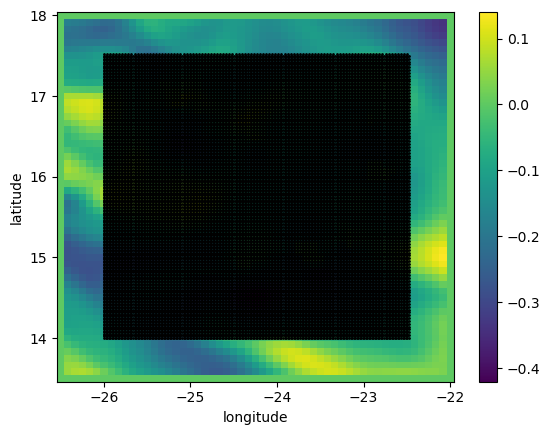

In [11]:
# Visual check of initial particle positions on top of the velocity field
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

## 5. Particle Advection

Particles are advected forward for **10 days** using the 4th-order Runge-Kutta (`AdvectionRK4`) kernel with a time step of 5 minutes. Before that, output of ParticleSet are saved to a Zarr file.

Two recovery kernels handle error states:
- `CheckOutOfBounds` — deletes particles that leave the domain
- `CheckError` — deletes particles in any other error state (state code ≥ 50)


In [12]:
output_file = pset.ParticleFile(
    name="CV_gridParticles.zarr",  # the file name
    outputdt=timedelta(hours=1),  # the time step of the outputs
)

print(output_file)

ParticleFile(name='CV_gridParticles.zarr', particleset=<parcels.particleset.ParticleSet object at 0x1554cc7d9d30>, outputdt=3600.0, chunks=None, create_new_zarrfile=True)


In [13]:
# Recovery kernels
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

# Build kernel
kernels = (
    pset.Kernel(parcels.AdvectionRK4)
    + pset.Kernel(CheckOutOfBounds)
)

# Execute
pset.execute(
    kernels,
    runtime=timedelta(days=10),
    dt=timedelta(minutes=5),
    #output_file=output_file,
)

100%|██████████| 864000.0/864000.0 [00:42<00:00, 20330.66it/s]


<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], sh

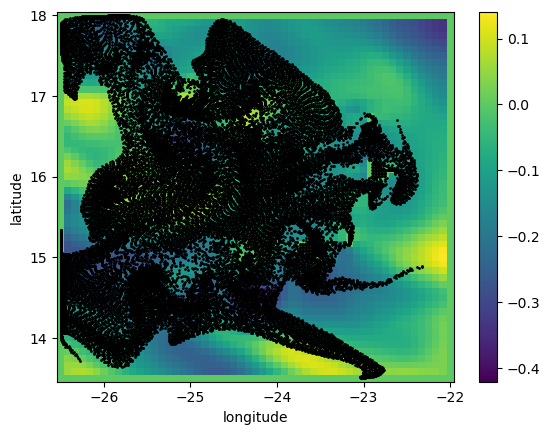

In [14]:
# visualisation of final particle position after advection
print(pset)

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize = 1)
plt.show()

## Deformation Gradient Tensor

The **deformation gradient tensor** $\mathbf{F}$ maps initial infinitesimal line elements to their final positions. It is estimated by finite differences using the triplet structure:

$$
\mathbf{F} = \begin{pmatrix} \partial X / \partial x & \partial X / \partial y \\ \partial Y / \partial x & \partial Y / \partial y \end{pmatrix}
$$

where $(X, Y)$ are the final positions and $(x, y)$ are the initial positions.

In [15]:
# final particle positions
final_lon = pset.lon
final_lat = pset.lat

print(f"Number of particles: {len(final_lon)}")

Number of particles: 30000


In [16]:
# split of final positions back into triplet groups
center = []
xshift = []
yshift = []

for i in range(0, len(final_lon), 3):
    center.append([final_lon[i], final_lat[i]])
    xshift.append([final_lon[i+1], final_lat[i+1]])
    yshift.append([final_lon[i+2], final_lat[i+2]])

center = np.array(center)
xshift = np.array(xshift)
yshift = np.array(yshift)

In [17]:
# finite-difference partial derivatives of the flow map computation
dXdx = (xshift[:, 0] - center[:, 0]) / delta  # ∂X/∂x
dYdx = (xshift[:, 1] - center[:, 1]) / delta  # ∂Y/∂x

dXdy = (yshift[:, 0] - center[:, 0]) / delta  # ∂X/∂y
dYdy = (yshift[:, 1] - center[:, 1]) / delta  # ∂Y/∂y

# deformation gradient tensor F (2x2 matrices of N_particles)
F = np.array([
    [dXdx, dXdy],
    [dYdx, dYdy],
])

print("F shape:", F.shape)

F shape: (2, 2, 10000)


## Cauchy-Green Strain Tensor computation

The **right Cauchy-Green strain tensor** is:

$$\mathbf{C} = \mathbf{F}^\top \mathbf{F}$$

Its maximum eigenvalue $\lambda_{\max}$ governs the maximum stretching, from which the FTLE is derived.

In [18]:
# C = F^T F  — using Einstein summation (k: column index of F)
C = np.einsum("kil,kjl->ijl", F, F)  # shape: (2, 2, N)

# Transpose to (N, 2, 2) for np.linalg.eig
C_T = np.transpose(C, (2, 0, 1))

print("C shape (per-particle matrices):", C_T.shape)

C shape (per-particle matrices): (10000, 2, 2)


In [19]:
# Compute eigenvalues and eigenvectors for each particle's C matrix
eigenvalues, eigenvectors = np.linalg.eig(C_T)

print("Eigenvalue array shape:", eigenvalues.shape)   # (N, 2)
print("Eigenvector array shape:", eigenvectors.shape)  # (N, 2, 2)

Eigenvalue array shape: (10000, 2)
Eigenvector array shape: (10000, 2, 2)


In [20]:
# Maximum eigenvalue for each particle
ev_max = np.where(
    (np.argmax(eigenvalues, axis=1) == 0)[:, np.newaxis],
    eigenvectors[:, 0, :],
    eigenvectors[:, 1, :],
)

print("Dominant eigenvectors shape:", ev_max.shape)  # (N, 2)

Dominant eigenvectors shape: (10000, 2)


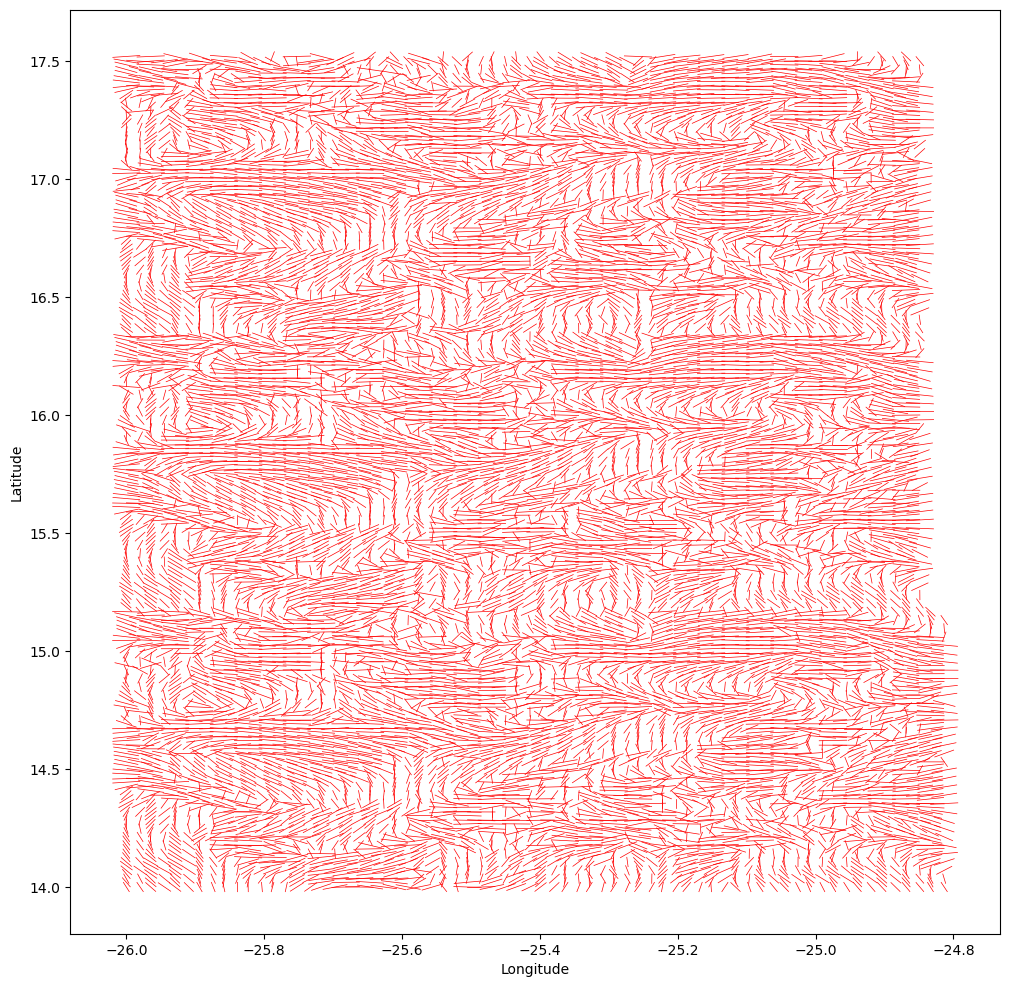

In [21]:
# eigenvector directions (first 10,000 particles)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for n in range(min(eigenvector_plot_count, len(ev_max))):
    _x = [lons[n] + delta * ev_max[n, 0], lons[n] - delta * ev_max[n, 0]]
    _y = [lats[n] + delta * ev_max[n, 1], lats[n] - delta * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## LCS map

The **LCS** map for the Cabo Verde region was computed from $\lambda_{\max}$, which is the maximum eigenvalue of $\mathbf{C}$. 

In [22]:
# Integration time in seconds (10 days)
T = integration_days * 24 * 60 * 60  # seconds
print(f"Integration time T = {T} s ({T/86400:.0f} days)")

# Maximum eigenvalues per particle
max_eigenvalues = np.max(eigenvalues, axis=1)

Integration time T = 864000 s (10 days)


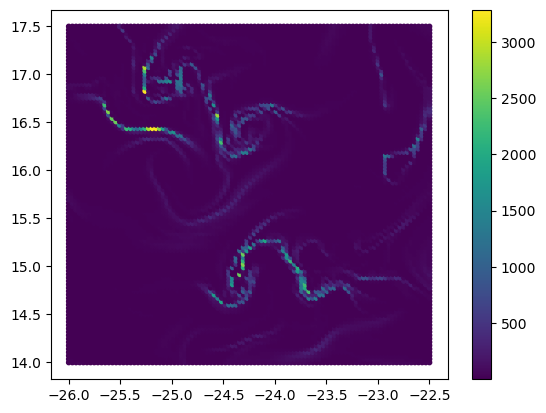

In [23]:
plt.scatter(lons[0::3], lats[0::3], 10, max_eigenvalues)
plt.colorbar()

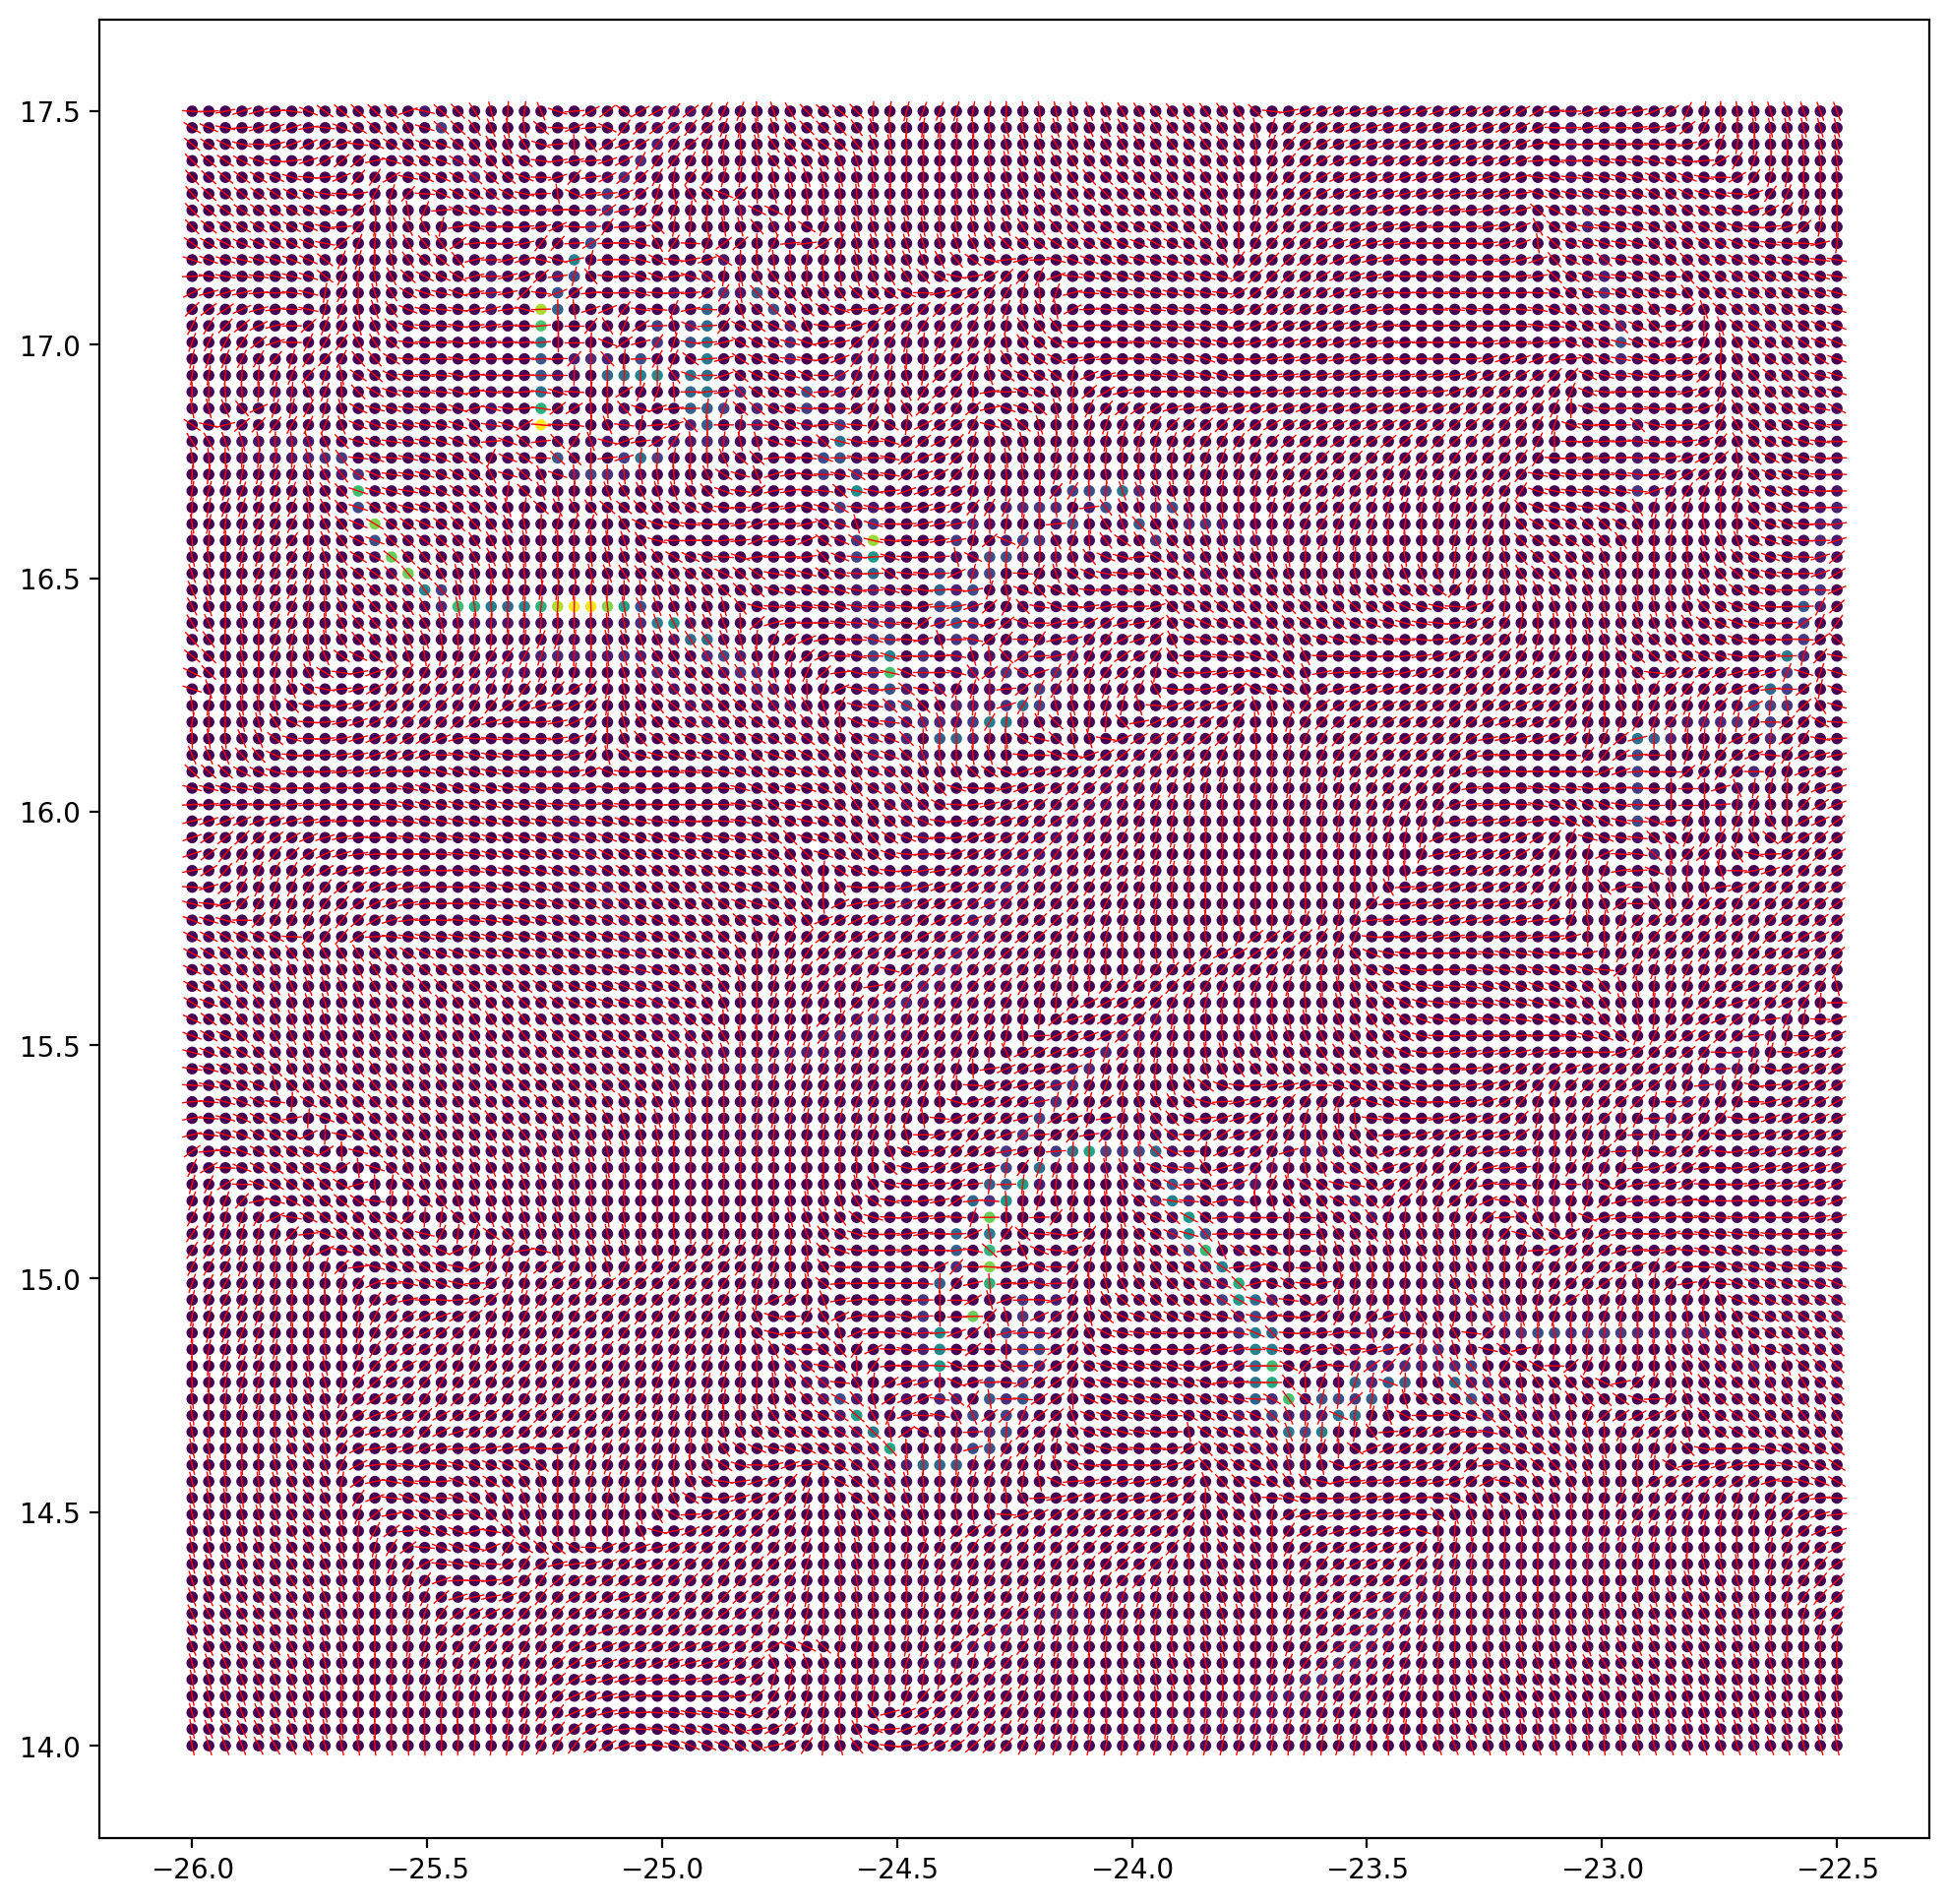

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

ax.scatter(lons[0::3], lats[0::3], 10, max_eigenvalues)

# Overlay dominant eigenvector orientations
for n in range(0,10000,1):
    _x = [lons[n*3] + delta * ev_max[n, 0], lons[n*3] - delta * ev_max[n, 0]]
    _y = [lats[n*3] + delta * ev_max[n, 1], lats[n*3] - delta * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

fig.set_dpi(200)
plt.show()